In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("CleanedCafeSalesData.csv")

In [3]:
df.columns

Index(['Unnamed: 0', 'Transaction ID', 'Price Per Unit', 'Quantity',
       'Total Spent', 'Item', 'Transaction Date', 'Payment Method',
       'Location'],
      dtype='object')

In [4]:
df = df[['Transaction ID', 'Price Per Unit', 'Quantity',
       'Total Spent', 'Item', 'Transaction Date', 'Payment Method',
       'Location']]

In [5]:
df.head()

,Transaction ID,Price Per Unit,Quantity,Total Spent,Item,Transaction Date,Payment Method,Location
0,TXN_1000555,1.5,1.0,1.5,Tea,2023-10-19,Credit Card,In-store
1,TXN_1001832,5.0,2.0,10.0,Salad,2023-10-19,Cash,Takeaway
2,TXN_1002457,1.0,5.0,5.0,Cookie,2023-09-29,Digital Wallet,Takeaway
3,TXN_1003246,3.0,2.0,6.0,Juice,2023-02-15,Digital Wallet,In-store
4,TXN_1004184,4.0,1.0,4.0,Smoothie,2023-05-18,Credit Card,In-store


In [6]:
df.dtypes

Transaction ID       object
Price Per Unit      float64
Quantity            float64
Total Spent         float64
Item                 object
Transaction Date     object
Payment Method       object
Location             object
dtype: object

In [7]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

In [8]:
df.dtypes

Transaction ID              object
Price Per Unit             float64
Quantity                   float64
Total Spent                float64
Item                        object
Transaction Date    datetime64[ns]
Payment Method              object
Location                    object
dtype: object

In [10]:
df['MonthYear'] = df['Transaction Date'].dt.to_period('M').dt.to_timestamp()

In [11]:
df.head()

,Transaction ID,Price Per Unit,Quantity,Total Spent,Item,Transaction Date,Payment Method,Location,MonthYear
0,TXN_1000555,1.5,1.0,1.5,Tea,2023-10-19,Credit Card,In-store,2023-10-01
1,TXN_1001832,5.0,2.0,10.0,Salad,2023-10-19,Cash,Takeaway,2023-10-01
2,TXN_1002457,1.0,5.0,5.0,Cookie,2023-09-29,Digital Wallet,Takeaway,2023-09-01
3,TXN_1003246,3.0,2.0,6.0,Juice,2023-02-15,Digital Wallet,In-store,2023-02-01
4,TXN_1004184,4.0,1.0,4.0,Smoothie,2023-05-18,Credit Card,In-store,2023-05-01


In [12]:
spentbymonth = df.groupby('MonthYear')['Total Spent'].sum().reset_index()

In [13]:
spentbymonth

,MonthYear,Total Spent
0,2023-01-01,7785.5
1,2023-02-01,6992.0
2,2023-03-01,7690.0
3,2023-04-01,7627.0
4,2023-05-01,7297.5
5,2023-06-01,7784.5
6,2023-07-01,7146.0
7,2023-08-01,7343.5
8,2023-09-01,7089.5
9,2023-10-01,7694.0


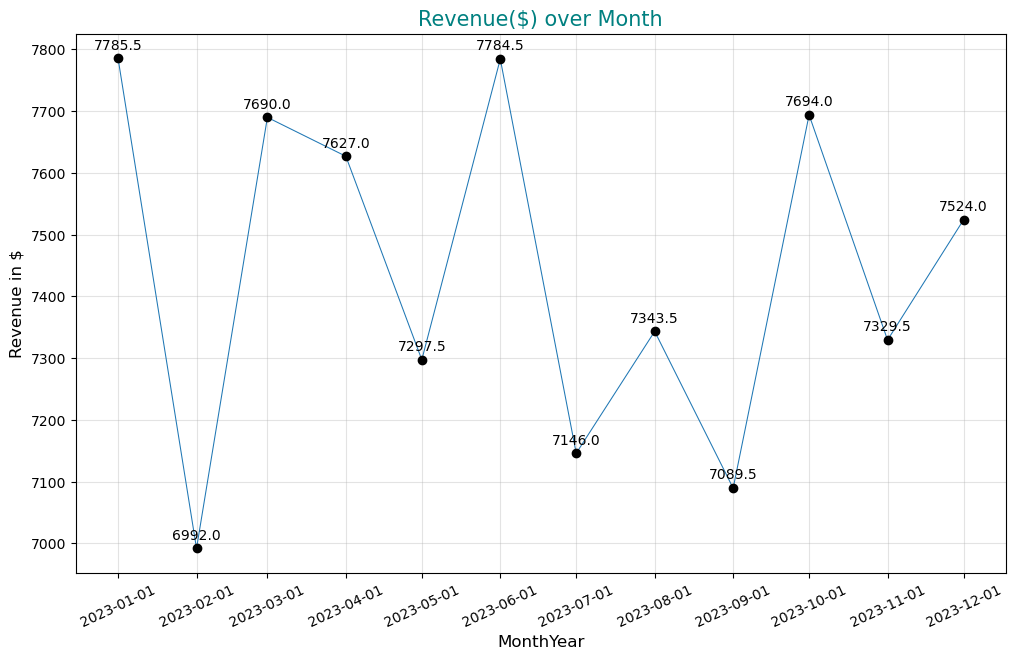

In [20]:
plt.figure(figsize=(12,7))
plt.plot(spentbymonth['MonthYear'],spentbymonth['Total Spent'], lw = 0.75, marker = 'o', mec = 'k', mfc = 'k')
plt.grid(alpha=0.35)
plt.xlabel("MonthYear",size=12)
plt.ylabel("Revenue in $",size=12)
plt.title("Revenue($) over Month",size=15,color='Teal')
plt.xticks(spentbymonth['MonthYear'], rotation=25)
for i in range(len(spentbymonth)):
    plt.text(spentbymonth['MonthYear'][i],spentbymonth['Total Spent'][i]+10,spentbymonth['Total Spent'][i],ha='center',va='bottom')
plt.show()

In [16]:
QuantityByMonth = df.groupby('MonthYear').agg(Orders=('Transaction ID','count'),ProductsSold=('Quantity','sum')).reset_index()

In [17]:
QuantityByMonth

,MonthYear,Orders,ProductsSold
0,2023-01-01,878,2645.0
1,2023-02-01,759,2365.0
2,2023-03-01,874,2620.0
3,2023-04-01,820,2529.0
4,2023-05-01,809,2446.0
5,2023-06-01,867,2612.0
6,2023-07-01,818,2430.0
7,2023-08-01,832,2502.0
8,2023-09-01,819,2450.0
9,2023-10-01,873,2656.0


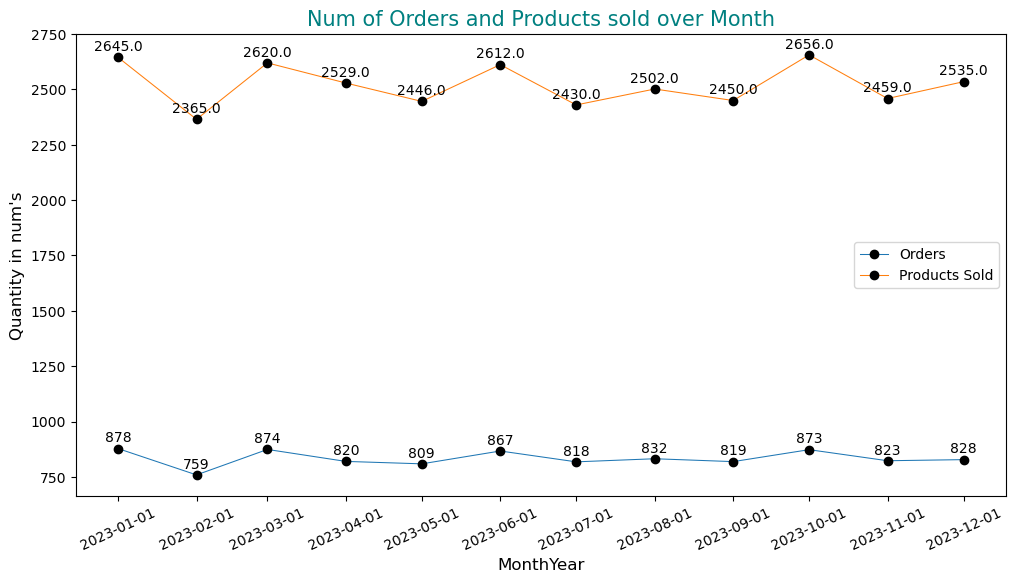

In [23]:
plt.figure(figsize=(12,6))
plt.plot(QuantityByMonth['MonthYear'],QuantityByMonth['Orders'],lw=0.75, marker='o',mec='k',mfc='k',label='Orders')
plt.plot(QuantityByMonth['MonthYear'],QuantityByMonth['ProductsSold'],lw=0.75, marker='o',mec='k',mfc='k',label='Products Sold')
plt.legend(loc="center right")
plt.xlabel("MonthYear", size=12)
plt.ylabel("Quantity in num's",size=12)
plt.xticks(QuantityByMonth['MonthYear'],rotation=25)
plt.title("Num of Orders and Products sold over Month", size = 15, color = 'Teal')
for i in range(len(QuantityByMonth)):
    plt.text(QuantityByMonth['MonthYear'][i],QuantityByMonth['Orders'][i]+30,QuantityByMonth['Orders'][i],ha='center')
    plt.text(QuantityByMonth['MonthYear'][i],QuantityByMonth['ProductsSold'][i]+30,QuantityByMonth['ProductsSold'][i],ha='center')
plt.show()

In [24]:
SpentByItem = df.groupby('Item')['Total Spent'].sum().reset_index()
SpentByItem

,Item,Total Spent
0,Cake,10413.0
1,Coffee,7853.0
2,Cookie,3616.0
3,Juice,12894.0
4,Salad,19113.0
5,Sandwich,16568.0
6,Smoothie,13362.0
7,Tea,5484.0


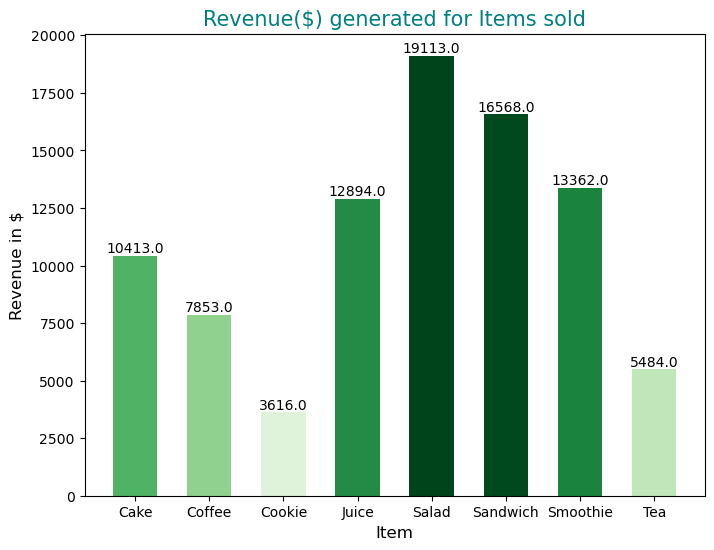

In [31]:
import matplotlib.cm as cm

NormalisedSpentByItem = ((SpentByItem['Total Spent']-SpentByItem['Total Spent'].min())/\
                        (SpentByItem['Total Spent'].max()-SpentByItem['Total Spent'].min()))+0.15

ColorsSpentByItem = cm.Greens(NormalisedSpentByItem)

plt.figure(figsize=(8,6))
plt.bar(SpentByItem['Item'],SpentByItem['Total Spent'],width=0.6,color=ColorsSpentByItem)
plt.xlabel("Item",size=12)
plt.ylabel("Revenue in $",size=12)
plt.title("Revenue($) generated for Items sold",size=15,color='Teal')
plt.xticks(SpentByItem['Item'])
for i in range(len(SpentByItem)):
    plt.text(SpentByItem['Item'][i],SpentByItem['Total Spent'][i]+10,SpentByItem['Total Spent'][i],ha='center',va='bottom')
plt.show()

In [32]:
OrdersByPayment = df.groupby('Payment Method')['Transaction ID'].count().reset_index()
OrdersByPayment

,Payment Method,Transaction ID
0,Cash,2998
1,Credit Card,2704
2,Digital Wallet,4298


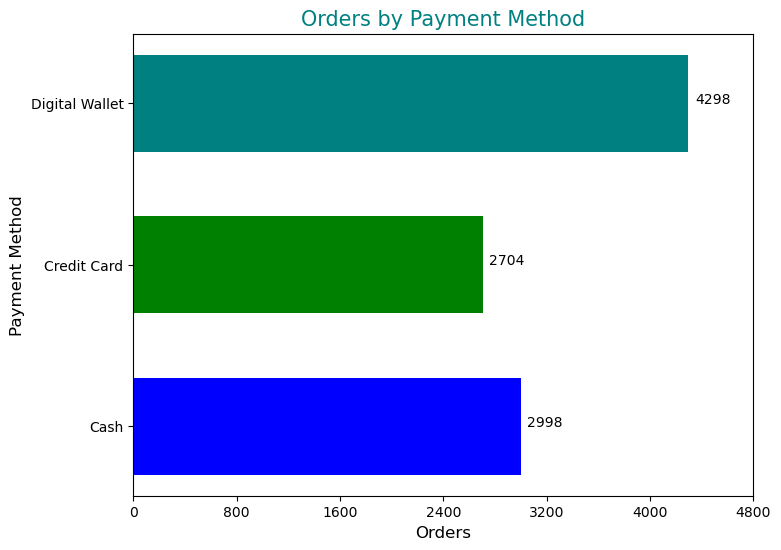

In [38]:
plt.figure(figsize=(8,6))
plt.barh(OrdersByPayment['Payment Method'],OrdersByPayment['Transaction ID'],height=0.6,color=['Blue','Green','Teal'])
plt.xlabel('Orders',size=12)
plt.ylabel('Payment Method',size=12)
plt.title("Orders by Payment Method",size=15,color='Teal')
for i in range(len(OrdersByPayment)):
    plt.text(OrdersByPayment['Transaction ID'][i]+50,OrdersByPayment['Payment Method'][i],OrdersByPayment['Transaction ID'][i])
plt.xticks(np.arange(0,5200,800))
plt.show()

In [39]:
OrdersByLoc = df.groupby('Location')['Transaction ID'].count().reset_index()
OrdersByLoc

,Location,Transaction ID
0,In-store,5522
1,Takeaway,4478


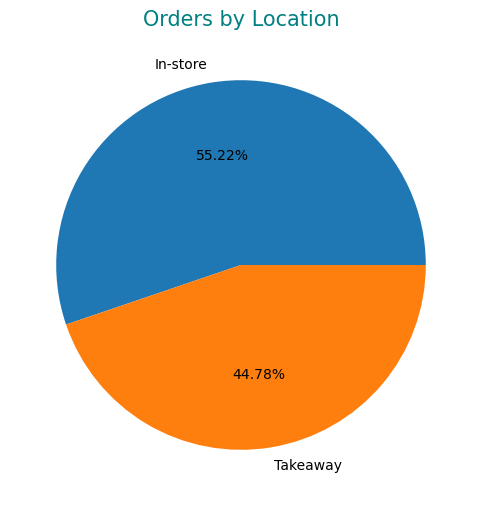

In [44]:
plt.figure(figsize=(6,6))
plt.pie(OrdersByLoc['Transaction ID'],labels=OrdersByLoc['Location'],autopct="%2.2f%%")
plt.title("Orders by Location",size=15,color='Teal')
plt.show()

In [45]:
QuanityByItem = df.groupby('Item')['Quantity'].sum().reset_index()
QuanityByItem

,Item,Quantity
0,Cake,3471.0
1,Coffee,3919.0
2,Cookie,3604.0
3,Juice,4290.0
4,Salad,3825.0
5,Sandwich,4145.0
6,Smoothie,3342.0
7,Tea,3653.0


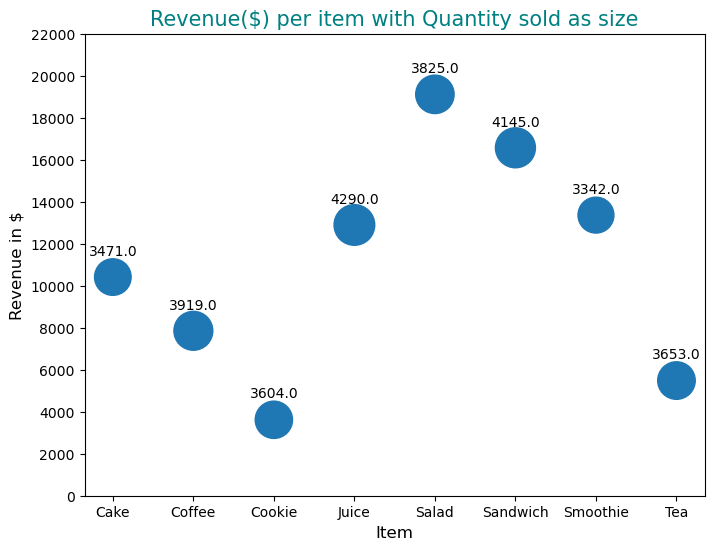

In [57]:
plt.figure(figsize=(8,6))
##ColorByItem = cm.viridis(SpentByItem)
plt.scatter(SpentByItem['Item'],SpentByItem['Total Spent'],s=(QuanityByItem['Quantity']/5))
for i in range(len(SpentByItem)):
    plt.text(SpentByItem['Item'][i],SpentByItem['Total Spent'][i]+900,QuanityByItem['Quantity'][i],ha='center',va='bottom')
plt.yticks(np.arange(0,24000,2000))
plt.xlabel("Item",size=12)
plt.ylabel("Revenue in $",size=12)
plt.title("Revenue($) per item with Quantity sold as size",size=15,color='Teal')
plt.show()
